# Chapter 11: Convex Sets

Source span: printed pages `331-384`, PDF pages `343-396` in `Geometry-I/Geometry-I.pdf`.

## Chapter Goal

Convexity turns the statement "every segment stays inside" into a system of certificates: positive affine combinations, support values, separating hyperplanes, finite intersection tests, and epigraph inequalities. This notebook rebuilds those certificates computationally so the chapter can be read without the scanned source open.

The local PDF span is image-only under text extraction. I used the course inventory/source map and rendered page inspection for orientation. The prose, diagrams, code, and checks below are original teaching material, not copied page text or page crops.


## Computational Translation Guide

| Chapter idea | Computational object | What we inspect |
| --- | --- | --- |
| Convex set | Predicate or sampled region closed under segment interpolation | Random segment tests and visible failure chords |
| Dimension and topology | Affine rank, ambient interior, relative interior, frontier samples | Why a segment in the plane has dimension 1 even though the ambient plane has dimension 2 |
| Convex hull | Smallest convex set generated by points | Positive weights, hull vertices, and support values |
| Separation and support | Linear inequality `u @ x <= h_K(u)` | Which side contains the convex body and how far an outside point violates the inequality |
| Halfspace description | Intersection of linear inequalities | 3D body whose vertices satisfy all inequalities |
| Helly theorem | Finite family of planar convex sets | Triple intersections versus whole-family intersection |
| Convex function | Convex epigraph in one higher dimension | Chords above the graph, Jensen residuals, and Hessian signs |

The chapter stays in finite-dimensional real affine spaces. Coordinates are used as a laboratory, but the invariants are affine or convex: segment containment, ranks, support inequalities, and intersection properties.


## Chapter-Specific Storyboard

The source route moves from definitions and examples to dimension/topology, separation/supporting hyperplanes, frontier and extreme points, Helly, and finally convex functions. The notebook implements that route with five concept-named visuals:

1. `convex-dimension-topology-map.png` compares full-dimensional and lower-dimensional convex sets, closure/frontier behavior, and a star-shaped nonconvex failure chord.
2. `convex-hull-support-separation-diagnostics.png` computes a hull, support lines, an outside point, and a separating line certified by a support inequality.
3. `halfspace-intersection-3d-body.html` shows a tetrahedron as an intersection of halfspaces in 3D.
4. `helly-finite-family-model.png` checks a finite planar Helly model and contrasts it with a pairwise-only failure.
5. `convex-function-epigraph-jensen.png` turns a function into an epigraph and checks Jensen inequalities against a nonconvex counterexample.

Library choices: Matplotlib gives durable labeled proof diagrams; SciPy supplies hulls; Shapely supplies planar intersection predicates; Plotly makes the 3D halfspace model inspectable; SymPy verifies derivative-based convexity criteria; Pandas records a small lab table.

The proof scaffolds in this notebook follow the same pattern. First, replace a geometric claim by a certificate that can be tested: an affine rank, a support value, an intersection area, or an inequality residual. Second, keep the certificate close to the picture so the learner can see what the theorem has to prove. Third, add a failure mode. The star-shaped panel shows that path-connected radial visibility is weaker than convexity. The Helly contrast shows that pairwise intersection is weaker than the triple test required in the plane. The epigraph contrast shows that one midpoint above one chord is enough to disprove convexity. These failures are not side examples; they identify the exact hypotheses that make the chapter's theorems work.


In [1]:
from __future__ import annotations

import itertools
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from scipy.spatial import ConvexHull
from shapely.geometry import LineString, Point, Polygon
from shapely.ops import nearest_points


def discover_book_root(start: Path | str = Path.cwd()) -> Path:
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Geometry-I.pdf").exists():
            return candidate
        nested = candidate / "Geometry-I"
        if (nested / "Geometry-I.pdf").exists():
            return nested
    raise RuntimeError("Could not locate Geometry-I/Geometry-I.pdf")


BOOK_ROOT = discover_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (  # noqa: E402
    assert_artifacts_nonempty,
    display_artifact,
    image_nonblank,
    relative_to_book,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)
from utils.geometry import support_function  # noqa: E402
from utils.plotting import COLORS  # noqa: E402

# Audit note: this chapter intentionally replaces the generic build_visual_suite path with direct, chapter-specific builders below.

TOPIC = "chapter-11"
TITLE = "Convex sets"
SOURCE_SPAN = {"printed": "331-384", "pdf": "343-396"}
PNG_DPI = 170
rng = np.random.default_rng(11011)

generated_artifacts: list[Path] = []
chapter_checks: dict[str, dict] = {}

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#bac4cf",
        "axes.grid": True,
        "grid.color": "#dfe5ec",
        "grid.linewidth": 0.75,
        "font.size": 9,
    }
)


def unit(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=float)
    norm = np.linalg.norm(v)
    if norm == 0:
        raise ValueError("zero vector has no direction")
    return v / norm


def set_equal_aspect(ax, xlim=None, ylim=None):
    ax.set_aspect("equal", adjustable="box")
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.tick_params(labelsize=8, colors=COLORS["gray"])


def plot_polygon_xy(ax, points, *, facecolor, edgecolor=COLORS["ink"], alpha=0.18, lw=1.8, label=None):
    pts = np.asarray(points, dtype=float)
    ax.fill(pts[:, 0], pts[:, 1], facecolor=facecolor, edgecolor=edgecolor, alpha=alpha, linewidth=lw, label=label)


def draw_line_by_normal(ax, normal, value, *, color, lw=1.6, alpha=1.0, label=None, span=4.0):
    n = unit(normal)
    tangent = np.array([-n[1], n[0]])
    center = value * n
    p0 = center - span * tangent
    p1 = center + span * tangent
    ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, lw=lw, alpha=alpha, label=label)


def intersection_all(geoms):
    geoms = list(geoms)
    result = geoms[0]
    for geom in geoms[1:]:
        result = result.intersection(geom)
    return result


def fill_shapely(ax, geom, *, color, alpha=0.25, edgecolor=None, lw=1.0, label=None):
    if geom.is_empty:
        return
    if geom.geom_type == "Polygon":
        xy = np.asarray(geom.exterior.coords)
        ax.fill(xy[:, 0], xy[:, 1], facecolor=color, edgecolor=edgecolor or color, alpha=alpha, linewidth=lw, label=label)
        for interior in geom.interiors:
            hole = np.asarray(interior.coords)
            ax.fill(hole[:, 0], hole[:, 1], facecolor="white", edgecolor=edgecolor or color, alpha=1.0, linewidth=lw)
    elif geom.geom_type == "MultiPolygon":
        for part in geom.geoms:
            fill_shapely(ax, part, color=color, alpha=alpha, edgecolor=edgecolor, lw=lw, label=label)
            label = None


def save_current_figure(fig, filename: str) -> Path:
    path = save_matplotlib(fig, TOPIC, filename, dpi=PNG_DPI)
    generated_artifacts.append(path)
    return path


setup_report = {
    "book_root": relative_to_book(BOOK_ROOT),
    "artifact_topic": TOPIC,
    "source_span": SOURCE_SPAN,
}
setup_report


{'book_root': '.',
 'artifact_topic': 'chapter-11',
 'source_span': {'printed': '331-384', 'pdf': '343-396'}}

## 1. Convexity, Dimension, and Topology

A convex set is tested by segments, but topology controls what those segment tests mean. A disk is full-dimensional in the plane; a segment is convex but has only relative interior inside its own affine span; the closure of a convex set stays convex; and a star-shaped set can still fail convexity when one chord exits the set.

Inspect the red chord in the fourth panel: both endpoints are inside the star-shaped region, but the segment between them leaves it. That single chord is a certificate of nonconvexity.


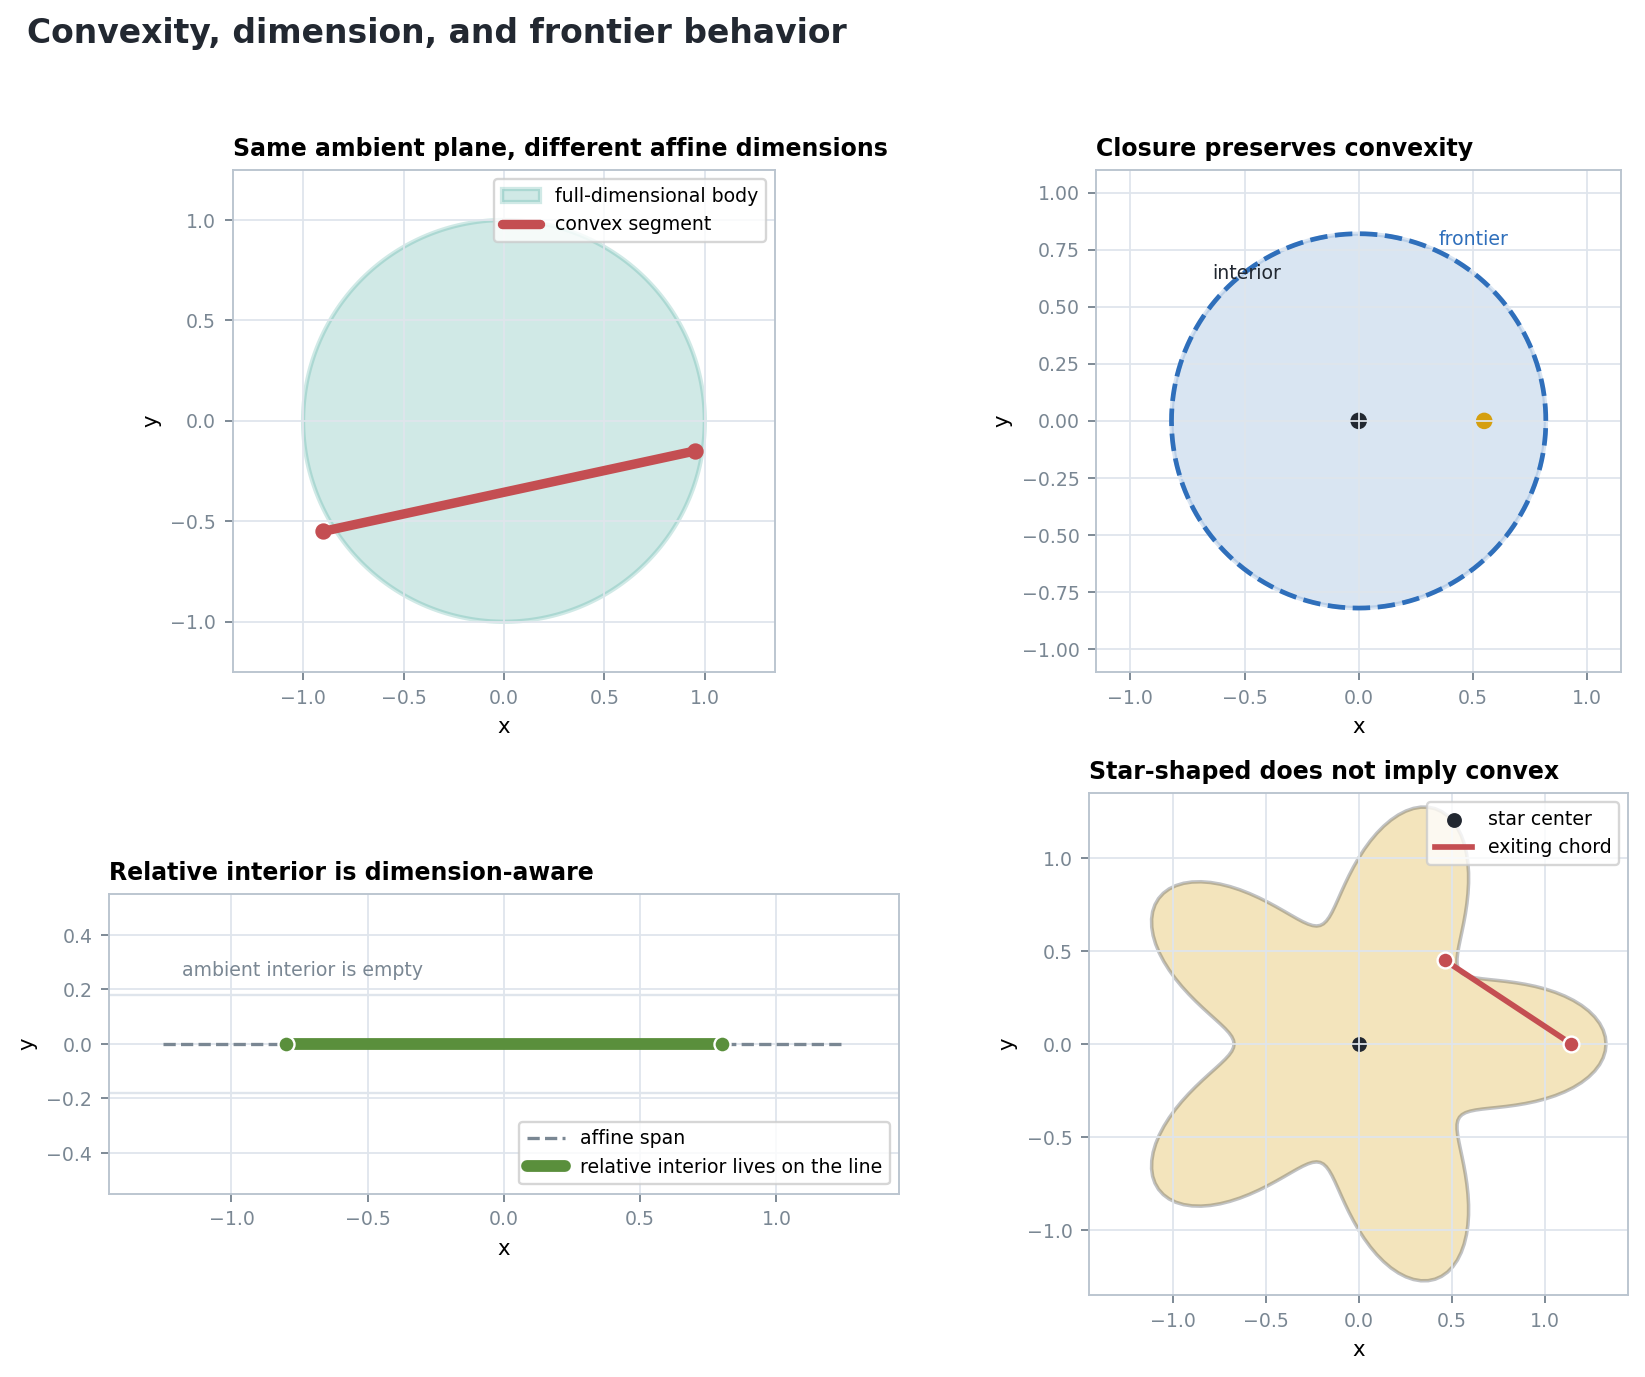

{'ambient_rank_disk_sample': 2,
 'segment_affine_rank': 1,
 'disk_random_segment_failures': 0,
 'star_chord_inside': False,
 'star_chord_escape_length': 0.0662542138827328}

In [2]:
def build_dimension_topology_artifact() -> tuple[Path, dict]:
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.2))
    fig.suptitle("Convexity, dimension, and frontier behavior", x=0.02, y=0.98, ha="left", fontsize=14, fontweight="bold", color=COLORS["ink"])

    theta = np.linspace(0, 2 * np.pi, 360, endpoint=False)
    circle = np.column_stack([np.cos(theta), np.sin(theta)])

    ax = axes[0, 0]
    plot_polygon_xy(ax, circle, facecolor=COLORS["teal"], edgecolor=COLORS["teal"], alpha=0.22, label="full-dimensional body")
    segment = np.array([[-0.9, -0.55], [0.95, -0.15]])
    ax.plot(segment[:, 0], segment[:, 1], color=COLORS["red"], lw=4, solid_capstyle="round", label="convex segment")
    ax.scatter(segment[:, 0], segment[:, 1], color=COLORS["red"], s=35, zorder=3)
    ax.set_title("Same ambient plane, different affine dimensions", loc="left", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    set_equal_aspect(ax, (-1.35, 1.35), (-1.25, 1.25))

    ax = axes[0, 1]
    open_disk = 0.82 * circle
    plot_polygon_xy(ax, open_disk, facecolor=COLORS["blue"], edgecolor=COLORS["blue"], alpha=0.18)
    ax.plot(open_disk[:, 0], open_disk[:, 1], color=COLORS["blue"], lw=2.0, linestyle="--", label="frontier added in closure")
    ax.scatter([0.0, 0.55], [0.0, 0.0], color=[COLORS["ink"], COLORS["gold"]], s=36)
    ax.text(-0.64, 0.62, "interior", fontsize=8, color=COLORS["ink"])
    ax.text(0.35, 0.77, "frontier", fontsize=8, color=COLORS["blue"])
    ax.set_title("Closure preserves convexity", loc="left", fontsize=10, fontweight="bold")
    set_equal_aspect(ax, (-1.15, 1.15), (-1.1, 1.1))

    ax = axes[1, 0]
    affine_line = np.array([[-1.25, 0.0], [1.25, 0.0]])
    rel_segment = np.array([[-0.8, 0.0], [0.8, 0.0]])
    ax.plot(affine_line[:, 0], affine_line[:, 1], color=COLORS["gray"], lw=1.4, linestyle="--", label="affine span")
    ax.plot(rel_segment[:, 0], rel_segment[:, 1], color=COLORS["green"], lw=5, solid_capstyle="round", label="relative interior lives on the line")
    ax.scatter(rel_segment[:, 0], rel_segment[:, 1], color=COLORS["green"], edgecolor="white", s=46, zorder=3)
    ax.axhline(0.18, color="#dfe5ec", lw=1.0)
    ax.axhline(-0.18, color="#dfe5ec", lw=1.0)
    ax.text(-1.18, 0.25, "ambient interior is empty", fontsize=8, color=COLORS["gray"])
    ax.set_title("Relative interior is dimension-aware", loc="left", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="lower right")
    set_equal_aspect(ax, (-1.45, 1.45), (-0.55, 0.55))

    star_theta = np.linspace(0, 2 * np.pi, 220, endpoint=False)
    radius = 1.0 + 0.33 * np.cos(5 * star_theta)
    star = np.column_stack([radius * np.cos(star_theta), radius * np.sin(star_theta)])
    star_poly = Polygon(star)
    samples = np.column_stack([0.86 * radius * np.cos(star_theta), 0.86 * radius * np.sin(star_theta)])
    bad_pair = None
    for i, j in itertools.combinations(range(0, len(samples), 3), 2):
        chord = LineString([samples[i], samples[j]])
        if not star_poly.buffer(1e-9).covers(chord):
            bad_pair = (samples[i], samples[j], chord)
            break
    if bad_pair is None:
        raise AssertionError("could not find a nonconvex chord in the star-shaped sample")

    ax = axes[1, 1]
    plot_polygon_xy(ax, star, facecolor=COLORS["gold"], edgecolor=COLORS["ink"], alpha=0.28, lw=1.5)
    a, b, chord = bad_pair
    ax.scatter([0], [0], color=COLORS["ink"], s=28, label="star center")
    ax.plot([a[0], b[0]], [a[1], b[1]], color=COLORS["red"], lw=2.4, label="exiting chord")
    ax.scatter([a[0], b[0]], [a[1], b[1]], color=COLORS["red"], edgecolor="white", s=45, zorder=4)
    ax.set_title("Star-shaped does not imply convex", loc="left", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    set_equal_aspect(ax, (-1.45, 1.45), (-1.35, 1.35))

    for ax in axes.flat:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    path = save_current_figure(fig, "convex-dimension-topology-map.png")

    disk_failures = 0
    for _ in range(250):
        r1, r2 = np.sqrt(rng.random(2))
        t1, t2 = rng.random(2) * 2 * np.pi
        p = r1 * np.array([math.cos(t1), math.sin(t1)])
        q = r2 * np.array([math.cos(t2), math.sin(t2)])
        lam = rng.random()
        candidate = lam * p + (1 - lam) * q
        disk_failures += int(np.linalg.norm(candidate) > 1 + 1e-12)

    checks = {
        "ambient_rank_disk_sample": 2,
        "segment_affine_rank": int(np.linalg.matrix_rank((segment[1:] - segment[:1]))),
        "disk_random_segment_failures": int(disk_failures),
        "star_chord_inside": bool(star_poly.buffer(1e-9).covers(chord)),
        "star_chord_escape_length": float(chord.difference(star_poly).length),
    }
    return path, checks


dimension_path, dimension_checks = build_dimension_topology_artifact()
chapter_checks["dimension_topology"] = dimension_checks

display_artifact(dimension_path, width=860)
dimension_checks


## 2. Convex Hulls, Support, and Separation

The convex hull of finitely many points is the set of their positive affine combinations. A support function packages all possible supporting lines into one scalar function

$$h_K(u) = \max_{x \in K} u \cdot x.$$

If a point lies outside a closed convex set, a nearest boundary point gives a normal direction. The line perpendicular to that normal separates the point from the convex body. In the figure, inspect the red normal and the signed margin: the hull lies on one side of the red line and the outside point lies strictly on the other.


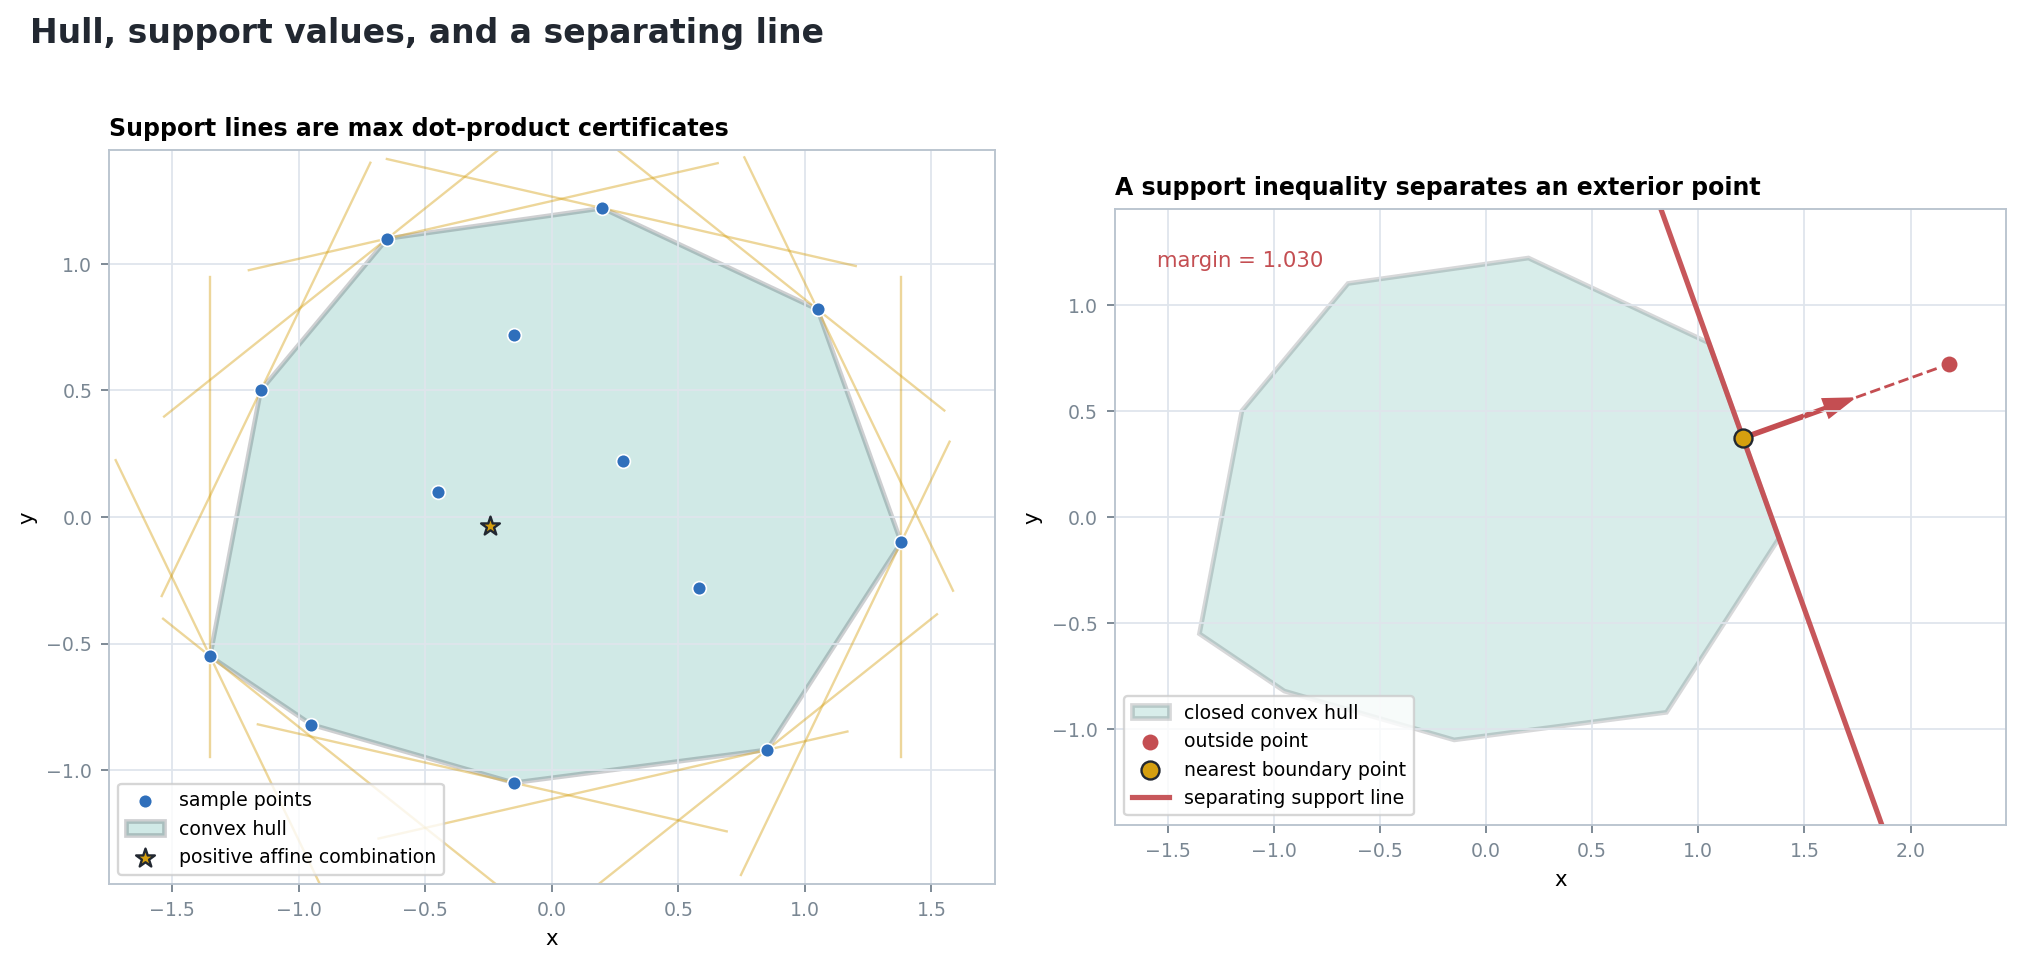

{'input_points': 13,
 'hull_vertices': 9,
 'support_residual_max': 0.0,
 'separating_margin': 1.0298809790180412,
 'hull_side_residual_at_separator': 0.0,
 'outside_point_violates_separator': True,
 'positive_weights_min': 0.07407407407407407,
 'positive_weights_sum': 0.9999999999999999,
 'barycentric_reconstruction_error': 0.0,
 'outside_point_in_hull': False}

In [3]:
def build_hull_support_separation_artifact() -> tuple[Path, dict]:
    points = np.array(
        [
            [-1.35, -0.55], [-1.15, 0.50], [-0.65, 1.10], [0.20, 1.22], [1.05, 0.82],
            [1.38, -0.10], [0.85, -0.92], [-0.15, -1.05], [-0.95, -0.82],
            [-0.45, 0.10], [0.28, 0.22], [0.58, -0.28], [-0.15, 0.72],
        ],
        dtype=float,
    )
    hull = ConvexHull(points)
    hull_pts = points[hull.vertices]
    hull_poly = Polygon(hull_pts)

    angles = np.linspace(0, 2 * np.pi, 14, endpoint=False)
    directions = np.column_stack([np.cos(angles), np.sin(angles)])
    supports = support_function(hull_pts, directions)

    outside = np.array([2.18, 0.72])
    nearest_geom = nearest_points(hull_poly.boundary, Point(outside))[0]
    nearest = np.array(nearest_geom.coords[0])
    normal = unit(outside - nearest)
    support_at_normal = float(normal @ nearest)
    separation_margin = float(normal @ outside - support_at_normal)
    hull_side_residual = float(np.max(hull_pts @ normal - support_at_normal))

    weights = np.linspace(1.0, 2.0, len(hull_pts))
    weights = weights / weights.sum()
    bary_point = weights @ hull_pts
    bary_error = float(np.linalg.norm(bary_point - weights @ hull_pts))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
    fig.suptitle("Hull, support values, and a separating line", x=0.02, y=0.98, ha="left", fontsize=14, fontweight="bold", color=COLORS["ink"])

    ax = axes[0]
    ax.scatter(points[:, 0], points[:, 1], s=34, color=COLORS["blue"], edgecolor="white", linewidth=0.7, zorder=3, label="sample points")
    plot_polygon_xy(ax, hull_pts, facecolor=COLORS["teal"], edgecolor=COLORS["ink"], alpha=0.22, lw=2.0, label="convex hull")
    ax.scatter([bary_point[0]], [bary_point[1]], s=70, marker="*", color=COLORS["gold"], edgecolor=COLORS["ink"], zorder=5, label="positive affine combination")
    for direction, value in zip(directions, supports):
        draw_line_by_normal(ax, direction, value, color=COLORS["gold"], lw=1.0, alpha=0.42, span=0.95)
    ax.set_title("Support lines are max dot-product certificates", loc="left", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="lower left")
    set_equal_aspect(ax, (-1.75, 1.75), (-1.45, 1.45))

    ax = axes[1]
    plot_polygon_xy(ax, hull_pts, facecolor=COLORS["teal"], edgecolor=COLORS["ink"], alpha=0.18, lw=2.0, label="closed convex hull")
    ax.scatter([outside[0]], [outside[1]], s=60, color=COLORS["red"], edgecolor="white", zorder=4, label="outside point")
    ax.scatter([nearest[0]], [nearest[1]], s=58, color=COLORS["gold"], edgecolor=COLORS["ink"], zorder=4, label="nearest boundary point")
    draw_line_by_normal(ax, normal, support_at_normal, color=COLORS["red"], lw=2.2, alpha=0.95, label="separating support line", span=2.2)
    ax.arrow(nearest[0], nearest[1], 0.55 * normal[0], 0.55 * normal[1], color=COLORS["red"], width=0.015, head_width=0.09, length_includes_head=True)
    ax.plot([nearest[0], outside[0]], [nearest[1], outside[1]], color=COLORS["red"], lw=1.2, linestyle="--")
    ax.text(-1.55, 1.18, f"margin = {separation_margin:.3f}", fontsize=9, color=COLORS["red"])
    ax.set_title("A support inequality separates an exterior point", loc="left", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="lower left")
    set_equal_aspect(ax, (-1.75, 2.45), (-1.45, 1.45))

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.tight_layout(rect=(0, 0, 1, 0.92))
    path = save_current_figure(fig, "convex-hull-support-separation-diagnostics.png")

    support_residual = float(np.max(points @ directions.T - supports))
    checks = {
        "input_points": int(len(points)),
        "hull_vertices": int(len(hull_pts)),
        "support_residual_max": support_residual,
        "separating_margin": separation_margin,
        "hull_side_residual_at_separator": hull_side_residual,
        "outside_point_violates_separator": bool(separation_margin > 1e-8),
        "positive_weights_min": float(weights.min()),
        "positive_weights_sum": float(weights.sum()),
        "barycentric_reconstruction_error": bary_error,
        "outside_point_in_hull": bool(hull_poly.covers(Point(outside))),
    }
    return path, checks


hull_path, hull_checks = build_hull_support_separation_artifact()
chapter_checks["hull_support_separation"] = hull_checks

display_artifact(hull_path, width=900)
hull_checks


## 3. Halfspace Intersections in Three Dimensions

The chapter repeatedly uses the idea that halfspaces are convex and intersections of convex sets stay convex. The interactive tetrahedron is the intersection of four halfspaces:

$$x \ge 0,\quad y \ge 0,\quad z \ge 0,\quad x+y+z \le 1.$$

Rotate the HTML view and inspect that each face is a boundary hyperplane. The check records that every vertex satisfies every inequality.


In [4]:
def build_halfspace_3d_artifact() -> tuple[Path, dict]:
    vertices = np.array(
        [
            [0.0, 0.0, 0.0],
            [1.0, 0.0, 0.0],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 1.0],
        ]
    )
    faces = np.array([[0, 1, 2], [0, 1, 3], [0, 2, 3], [1, 2, 3]])
    A = np.array(
        [
            [-1.0, 0.0, 0.0],
            [0.0, -1.0, 0.0],
            [0.0, 0.0, -1.0],
            [1.0, 1.0, 1.0],
        ]
    )
    b = np.array([0.0, 0.0, 0.0, 1.0])

    fig = go.Figure()
    fig.add_trace(
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            color="#2a9d8f",
            opacity=0.45,
            name="halfspace intersection",
            hovertemplate="(%{x:.2f}, %{y:.2f}, %{z:.2f})<extra>vertex</extra>",
        )
    )
    edge_pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
    for a, c in edge_pairs:
        segment = vertices[[a, c]]
        fig.add_trace(
            go.Scatter3d(
                x=segment[:, 0],
                y=segment[:, 1],
                z=segment[:, 2],
                mode="lines",
                line={"color": "#222831", "width": 5},
                showlegend=False,
                hoverinfo="skip",
            )
        )
    face_names = ["z = 0", "y = 0", "x = 0", "x + y + z = 1"]
    for face, name in zip(faces, face_names):
        tri = vertices[face]
        tri = np.vstack([tri, tri[0]])
        fig.add_trace(
            go.Scatter3d(
                x=tri[:, 0],
                y=tri[:, 1],
                z=tri[:, 2],
                mode="lines",
                line={"color": "#d59f0f", "width": 3},
                name=name,
                hoverinfo="skip",
            )
        )
    fig.update_layout(
        title="Tetrahedron as an intersection of four halfspaces",
        margin={"l": 0, "r": 0, "t": 45, "b": 0},
        scene={
            "xaxis_title": "x",
            "yaxis_title": "y",
            "zaxis_title": "z",
            "aspectmode": "data",
            "camera": {"eye": {"x": 1.55, "y": 1.45, "z": 1.2}},
        },
        legend={"x": 0.02, "y": 0.98},
    )
    path = save_plotly_html(fig, TOPIC, "halfspace-intersection-3d-body.html")
    generated_artifacts.append(path)

    violations = A @ vertices.T - b[:, None]
    checks = {
        "vertices": int(len(vertices)),
        "halfspaces": int(len(A)),
        "max_halfspace_violation": float(violations.max()),
        "volume": float(1.0 / 6.0),
        "all_vertices_feasible": bool(np.all(violations <= 1e-12)),
    }
    return path, checks


halfspace_path, halfspace_checks = build_halfspace_3d_artifact()
chapter_checks["halfspace_3d"] = halfspace_checks

display_artifact(halfspace_path, width="100%", height=560)
halfspace_checks


{'vertices': 4,
 'halfspaces': 4,
 'max_halfspace_violation': 0.0,
 'volume': 0.16666666666666666,
 'all_vertices_feasible': True}

## 4. A Finite Helly Model

In the plane, Helly's theorem says that for a finite family of convex sets it is enough to test all triples. The left panel gives a positive model: every triple intersects and the entire family intersects. The right panel shows why pairwise intersection is too weak in dimension two: three disks can overlap pairwise while having empty triple intersection.

The computation uses Shapely intersections, so the visual statement is backed by finite area checks rather than only by inspection.


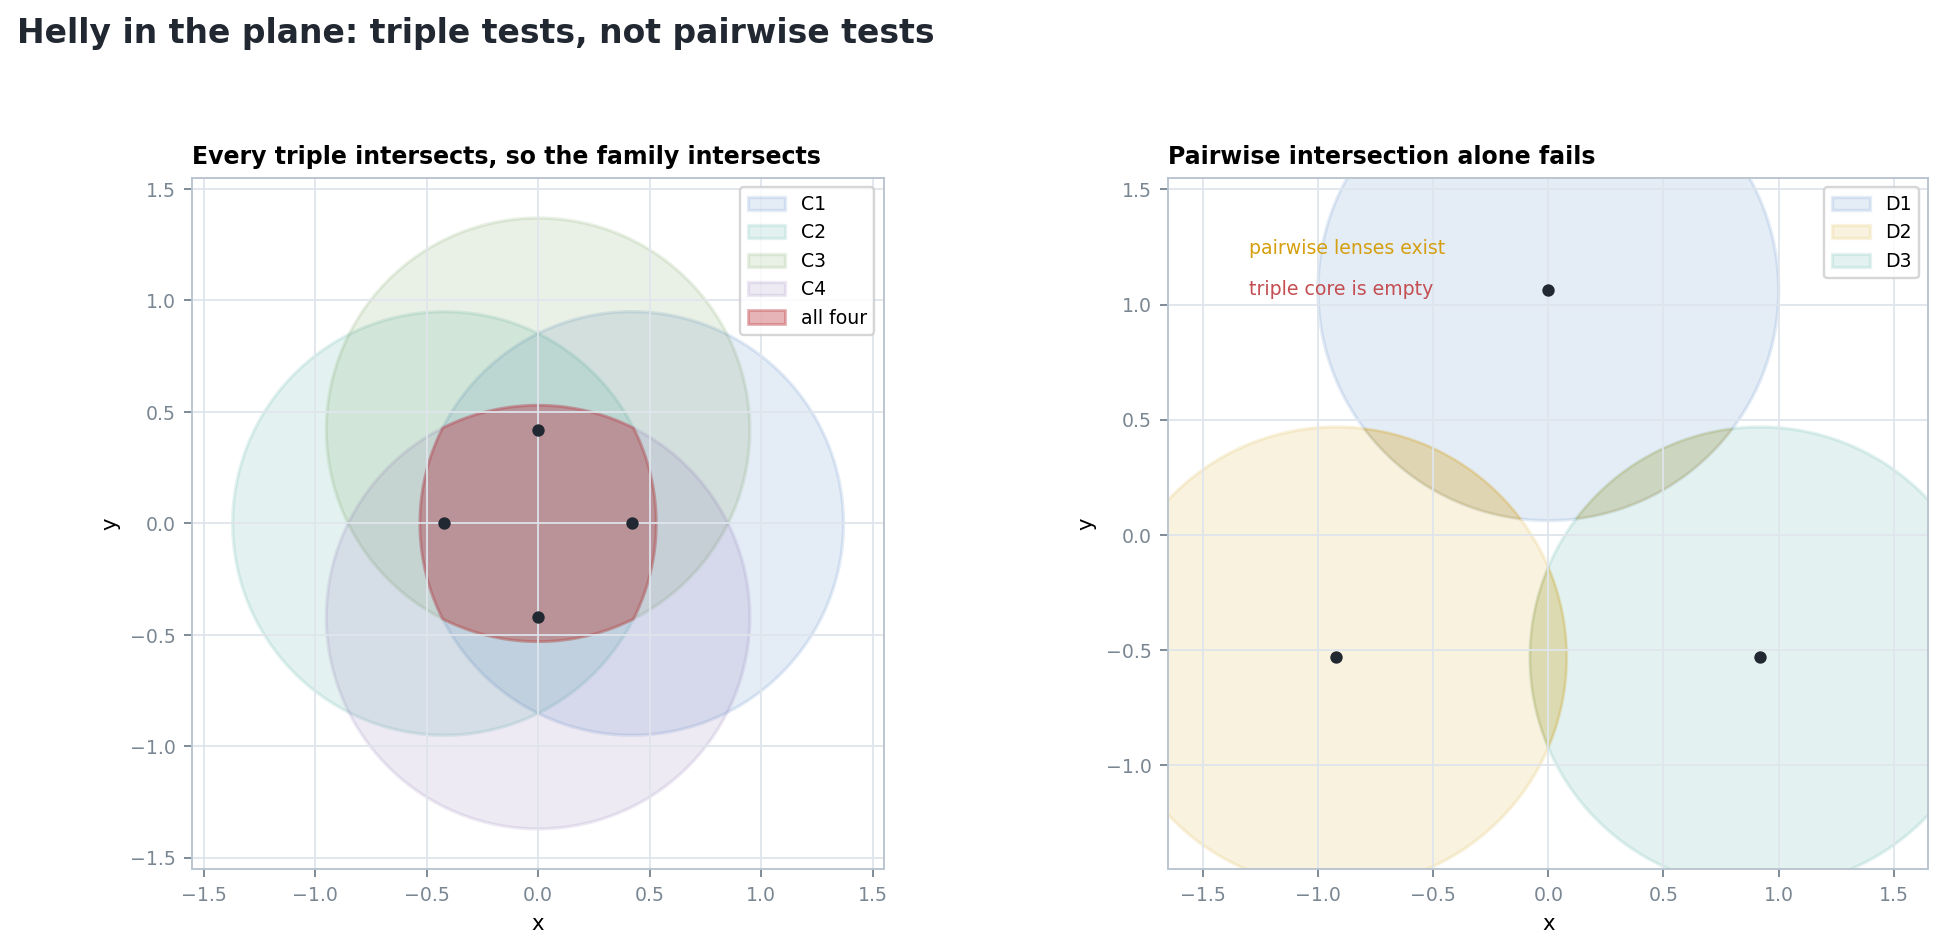

{'pass_family_count': 4,
 'pass_min_triple_area': 1.1305404424914125,
 'pass_global_intersection_area': 0.9682494216876044,
 'fail_pairwise_min_area': 0.08426589062633393,
 'fail_triple_intersection_area': 0.0,
 'pairwise_not_enough_in_plane': True}

In [5]:
def disk(center, radius):
    return Point(float(center[0]), float(center[1])).buffer(float(radius), quad_segs=96)


def build_helly_artifact() -> tuple[Path, dict]:
    pass_centers = np.array([[0.42, 0.0], [-0.42, 0.0], [0.0, 0.42], [0.0, -0.42]])
    pass_radius = 0.95
    pass_family = [disk(c, pass_radius) for c in pass_centers]
    pass_triples = [intersection_all(pass_family[i] for i in combo) for combo in itertools.combinations(range(4), 3)]
    pass_global = intersection_all(pass_family)

    side = 1.84
    fail_centers = np.array(
        [
            [0.0, math.sqrt(3) * side / 3],
            [-side / 2, -math.sqrt(3) * side / 6],
            [side / 2, -math.sqrt(3) * side / 6],
        ]
    )
    fail_radius = 1.0
    fail_family = [disk(c, fail_radius) for c in fail_centers]
    fail_pairs = [intersection_all(fail_family[i] for i in combo) for combo in itertools.combinations(range(3), 2)]
    fail_triple = intersection_all(fail_family)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
    fig.suptitle("Helly in the plane: triple tests, not pairwise tests", x=0.02, y=0.98, ha="left", fontsize=14, fontweight="bold", color=COLORS["ink"])

    ax = axes[0]
    colors = [COLORS["blue"], COLORS["teal"], COLORS["green"], COLORS["violet"]]
    for geom, color, idx in zip(pass_family, colors, range(1, 5)):
        fill_shapely(ax, geom, color=color, alpha=0.13, edgecolor=color, lw=1.4, label=f"C{idx}")
    fill_shapely(ax, pass_global, color=COLORS["red"], alpha=0.42, edgecolor=COLORS["red"], lw=1.2, label="all four")
    ax.scatter(pass_centers[:, 0], pass_centers[:, 1], color=COLORS["ink"], s=18, zorder=4)
    ax.set_title("Every triple intersects, so the family intersects", loc="left", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    set_equal_aspect(ax, (-1.55, 1.55), (-1.55, 1.55))

    ax = axes[1]
    for geom, color, idx in zip(fail_family, [COLORS["blue"], COLORS["gold"], COLORS["teal"]], range(1, 4)):
        fill_shapely(ax, geom, color=color, alpha=0.13, edgecolor=color, lw=1.4, label=f"D{idx}")
    for geom in fail_pairs:
        fill_shapely(ax, geom, color=COLORS["gold"], alpha=0.18, edgecolor=COLORS["gold"], lw=0.8)
    ax.scatter(fail_centers[:, 0], fail_centers[:, 1], color=COLORS["ink"], s=18, zorder=4)
    ax.text(-1.30, 1.22, "pairwise lenses exist", fontsize=8, color=COLORS["gold"])
    ax.text(-1.30, 1.04, "triple core is empty", fontsize=8, color=COLORS["red"])
    ax.set_title("Pairwise intersection alone fails", loc="left", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")
    set_equal_aspect(ax, (-1.65, 1.65), (-1.45, 1.55))

    for ax in axes:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.tight_layout(rect=(0, 0, 1, 0.92))
    path = save_current_figure(fig, "helly-finite-family-model.png")

    checks = {
        "pass_family_count": 4,
        "pass_min_triple_area": float(min(g.area for g in pass_triples)),
        "pass_global_intersection_area": float(pass_global.area),
        "fail_pairwise_min_area": float(min(g.area for g in fail_pairs)),
        "fail_triple_intersection_area": float(fail_triple.area),
        "pairwise_not_enough_in_plane": bool(min(g.area for g in fail_pairs) > 1e-4 and fail_triple.area < 1e-6),
    }
    return path, checks


helly_path, helly_checks = build_helly_artifact()
chapter_checks["helly_finite_model"] = helly_checks

display_artifact(helly_path, width=900)
helly_checks


## 5. Convex Functions and Epigraphs

A function is convex exactly when its epigraph is convex. In one dimension, this appears as the chord condition: the graph stays below every chord. The left panel shades the epigraph of a smooth convex function and samples Jensen inequalities. The right panel supplies a nonconvex contrast where the midpoint rises above the chord.

The symbolic check uses a second derivative criterion for the smooth example; the numerical check samples Jensen residuals and epigraph midpoint containment.


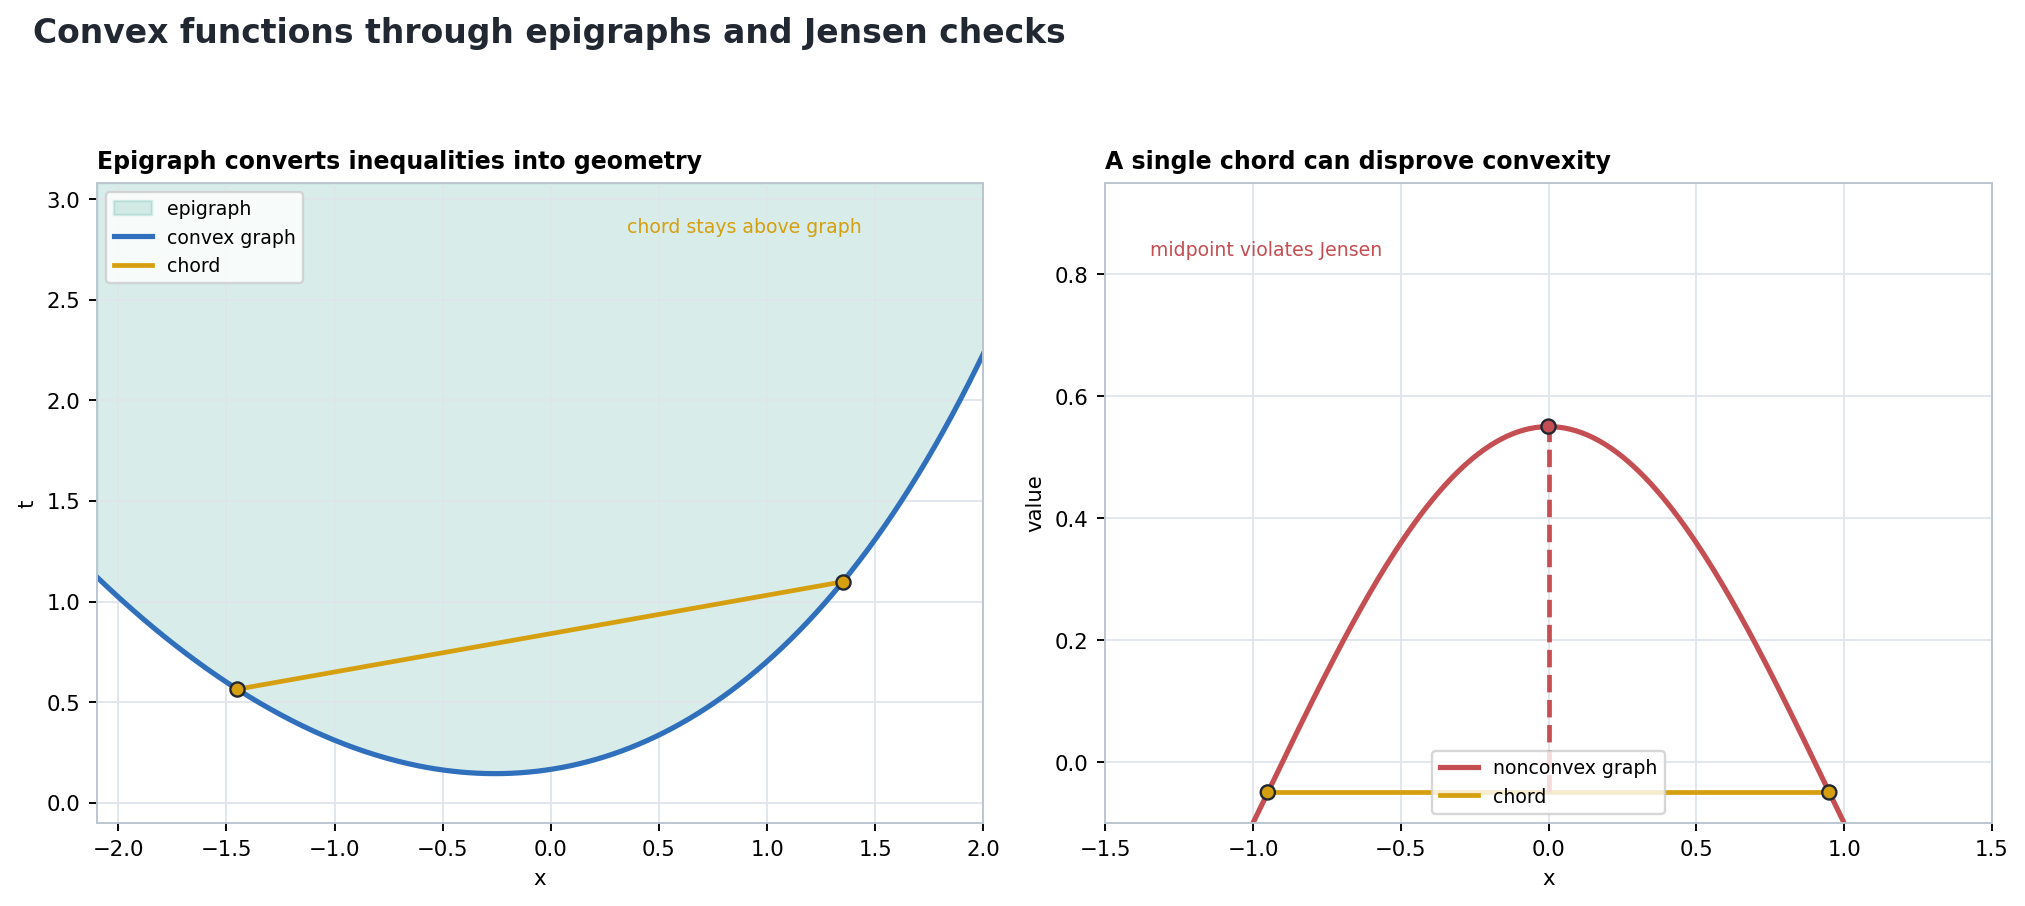

{'f_expression': 'x**2/4 + exp(x)/6',
 'f_second_derivative': '(exp(x) + 3)/6',
 'min_sample_second_derivative': 0.5225558805394355,
 'max_jensen_residual': -1.8243639410275847e-07,
 'epigraph_midpoint_min_slack': 0.09373811978825985,
 'nonconvex_midpoint_violation': 0.5998240625,
 'jensen_sample_count': 350}

In [6]:
def build_epigraph_artifact() -> tuple[Path, dict]:
    x = sp.symbols("x", real=True)
    f_expr = x**2 / 4 + sp.exp(x) / 6
    f_second = sp.diff(f_expr, x, 2)
    f = sp.lambdify(x, f_expr, "numpy")

    def g(arr):
        arr = np.asarray(arr)
        return 0.15 * arr**4 - 0.8 * arr**2 + 0.55

    xs = np.linspace(-2.1, 2.0, 420)
    ys = np.asarray(f(xs), dtype=float)
    ymax = float(ys.max() + 0.85)
    a, b = -1.45, 1.35
    fa, fb = float(f(a)), float(f(b))
    chord_x = np.linspace(a, b, 120)
    chord_y = ((b - chord_x) / (b - a)) * fa + ((chord_x - a) / (b - a)) * fb

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
    fig.suptitle("Convex functions through epigraphs and Jensen checks", x=0.02, y=0.98, ha="left", fontsize=14, fontweight="bold", color=COLORS["ink"])

    ax = axes[0]
    ax.fill_between(xs, ys, ymax, color=COLORS["teal"], alpha=0.18, label="epigraph")
    ax.plot(xs, ys, color=COLORS["blue"], lw=2.2, label="convex graph")
    ax.plot(chord_x, chord_y, color=COLORS["gold"], lw=2.0, label="chord")
    ax.scatter([a, b], [fa, fb], color=COLORS["gold"], edgecolor=COLORS["ink"], zorder=4)
    ax.text(0.35, ymax - 0.25, "chord stays above graph", fontsize=8, color=COLORS["gold"])
    ax.set_title("Epigraph converts inequalities into geometry", loc="left", fontsize=10, fontweight="bold")
    ax.set_xlim(-2.1, 2.0)
    ax.set_ylim(-0.1, ymax)
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    ax.legend(fontsize=8, loc="upper left")

    ax = axes[1]
    gx = np.linspace(-1.45, 1.45, 300)
    gy = g(gx)
    c, d = -0.95, 0.95
    gc, gd = float(g(c)), float(g(d))
    midpoint_value = float(g(0.0))
    chord_mid = 0.5 * (gc + gd)
    chord_x2 = np.linspace(c, d, 100)
    chord_y2 = ((d - chord_x2) / (d - c)) * gc + ((chord_x2 - c) / (d - c)) * gd
    ax.plot(gx, gy, color=COLORS["red"], lw=2.2, label="nonconvex graph")
    ax.plot(chord_x2, chord_y2, color=COLORS["gold"], lw=2.0, label="chord")
    ax.scatter([c, d, 0.0], [gc, gd, midpoint_value], color=[COLORS["gold"], COLORS["gold"], COLORS["red"]], edgecolor=COLORS["ink"], zorder=4)
    ax.vlines(0.0, chord_mid, midpoint_value, color=COLORS["red"], lw=2, linestyle="--")
    ax.text(-1.35, 0.83, "midpoint violates Jensen", fontsize=8, color=COLORS["red"])
    ax.set_title("A single chord can disprove convexity", loc="left", fontsize=10, fontweight="bold")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.1, 0.95)
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    ax.legend(fontsize=8, loc="lower center")

    fig.tight_layout(rect=(0, 0, 1, 0.92))
    path = save_current_figure(fig, "convex-function-epigraph-jensen.png")

    sample_a = rng.uniform(-2.0, 2.0, 350)
    sample_b = rng.uniform(-2.0, 2.0, 350)
    lambdas = rng.uniform(0.0, 1.0, 350)
    mixed = lambdas * sample_a + (1 - lambdas) * sample_b
    jensen_residuals = f(mixed) - (lambdas * f(sample_a) + (1 - lambdas) * f(sample_b))

    x1 = rng.uniform(-1.7, 1.7, 200)
    x2 = rng.uniform(-1.7, 1.7, 200)
    slack1 = rng.uniform(0.05, 0.9, 200)
    slack2 = rng.uniform(0.05, 0.9, 200)
    t1 = f(x1) + slack1
    t2 = f(x2) + slack2
    lam = rng.uniform(0.0, 1.0, 200)
    xm = lam * x1 + (1 - lam) * x2
    tm = lam * t1 + (1 - lam) * t2
    epigraph_slack = tm - f(xm)

    f_second_samples = np.array([float(f_second.subs(x, value)) for value in np.linspace(-2, 2, 17)])
    nonconvex_violation = float(midpoint_value - chord_mid)

    checks = {
        "f_expression": str(f_expr),
        "f_second_derivative": str(f_second),
        "min_sample_second_derivative": float(f_second_samples.min()),
        "max_jensen_residual": float(np.max(jensen_residuals)),
        "epigraph_midpoint_min_slack": float(np.min(epigraph_slack)),
        "nonconvex_midpoint_violation": nonconvex_violation,
        "jensen_sample_count": int(len(jensen_residuals)),
    }
    return path, checks


epigraph_path, epigraph_checks = build_epigraph_artifact()
chapter_checks["convex_function_epigraph"] = epigraph_checks

display_artifact(epigraph_path, width=900)
epigraph_checks


## Applied Lab: When Pairwise Overlap Becomes a Helly Triple

The right panel in the Helly figure used three equal disks whose pairwise intersections exist but whose triple intersection is empty. The lab varies the radius and records when the triple intersection appears. For three centers forming an equilateral triangle with side length `s`, the triple core begins when the radius reaches the circumradius `s / sqrt(3)`, while pairwise overlap begins earlier at `s / 2`.


In [7]:
def run_helly_radius_lab() -> tuple[pd.DataFrame, Path, dict]:
    side = 1.84
    centers = np.array(
        [
            [0.0, math.sqrt(3) * side / 3],
            [-side / 2, -math.sqrt(3) * side / 6],
            [side / 2, -math.sqrt(3) * side / 6],
        ]
    )
    rows = []
    for radius in np.linspace(0.88, 1.15, 10):
        family = [disk(c, radius) for c in centers]
        pair_areas = [intersection_all(family[i] for i in combo).area for combo in itertools.combinations(range(3), 2)]
        triple_area = intersection_all(family).area
        rows.append(
            {
                "radius": float(radius),
                "min_pairwise_area": float(min(pair_areas)),
                "triple_area": float(triple_area),
                "pairwise_nonempty": bool(min(pair_areas) > 1e-6),
                "helly_triple_nonempty": bool(triple_area > 1e-6),
            }
        )
    df = pd.DataFrame(rows)
    path = save_csv(rows, TOPIC, "helly-radius-threshold-lab.csv")
    generated_artifacts.append(path)
    checks = {
        "side_length": side,
        "pairwise_threshold": float(side / 2),
        "triple_threshold": float(side / math.sqrt(3)),
        "first_sample_with_triple": float(df.loc[df["helly_triple_nonempty"], "radius"].iloc[0]),
        "triple_area_monotone_nondec": bool(np.all(np.diff(df["triple_area"].to_numpy()) >= -1e-9)),
    }
    return df, path, checks


helly_lab_df, helly_lab_path, helly_lab_checks = run_helly_radius_lab()
chapter_checks["helly_radius_lab"] = helly_lab_checks
helly_lab_df


,radius,min_pairwise_area,triple_area,pairwise_nonempty,helly_triple_nonempty
0,0.88,0.000000,0.000000,False,False
1,0.91,0.000000,0.000000,False,False
2,0.94,0.010292,0.000000,True,False
3,0.97,0.041177,0.000000,True,False
4,1.00,0.084266,0.000000,True,False
5,1.03,0.137331,0.000000,True,False
6,1.06,0.199259,0.000000,True,False
7,1.09,0.269366,0.003877,True,True
8,1.12,0.347187,0.016470,True,True
9,1.15,0.432385,0.037299,True,True


## Final Sanity Checks

The final cell turns the lesson into an auditable record. It asserts that every generated artifact exists, that PNGs are nonblank, that the support and separation inequalities hold, that the Helly model has the intended intersections, that the halfspace vertices are feasible, and that the convex function checks satisfy Jensen and epigraph containment.


In [8]:
# Concept-level assertions.
assert dimension_checks["segment_affine_rank"] == 1
assert dimension_checks["disk_random_segment_failures"] == 0
assert dimension_checks["star_chord_inside"] is False
assert dimension_checks["star_chord_escape_length"] > 0

assert hull_checks["support_residual_max"] <= 1e-10
assert hull_checks["separating_margin"] > 0
assert hull_checks["hull_side_residual_at_separator"] <= 1e-8
assert hull_checks["outside_point_violates_separator"] is True
assert abs(hull_checks["positive_weights_sum"] - 1.0) < 1e-12
assert hull_checks["positive_weights_min"] > 0

assert halfspace_checks["all_vertices_feasible"] is True
assert halfspace_checks["max_halfspace_violation"] <= 1e-12
assert abs(halfspace_checks["volume"] - 1 / 6) < 1e-12

assert helly_checks["pass_min_triple_area"] > 1e-4
assert helly_checks["pass_global_intersection_area"] > 1e-4
assert helly_checks["fail_pairwise_min_area"] > 1e-4
assert helly_checks["fail_triple_intersection_area"] < 1e-6
assert helly_checks["pairwise_not_enough_in_plane"] is True

assert epigraph_checks["min_sample_second_derivative"] > 0
assert epigraph_checks["max_jensen_residual"] <= 1e-10
assert epigraph_checks["epigraph_midpoint_min_slack"] >= -1e-10
assert epigraph_checks["nonconvex_midpoint_violation"] > 0

assert helly_lab_checks["triple_area_monotone_nondec"] is True
assert helly_lab_checks["pairwise_threshold"] < helly_lab_checks["triple_threshold"]

png_artifacts = [dimension_path, hull_path, helly_path, epigraph_path]
check_path = save_json(chapter_checks, TOPIC, "convex-computation-checks.json")
generated_artifacts.append(check_path)

manifest_rows = []
for path in generated_artifacts:
    manifest_rows.append(
        {
            "artifact": relative_to_book(path),
            "bytes": int(path.stat().st_size),
            "kind": path.parent.name,
        }
    )
manifest_path = save_csv(manifest_rows, TOPIC, "artifact-manifest.csv")

visual_summary = {
    "title": TITLE,
    "source_span": SOURCE_SPAN,
    "artifact_topic": TOPIC,
    "storyboard_items": [
        "dimension_topology",
        "hull_support_separation",
        "halfspace_3d",
        "helly_finite_model",
        "convex_function_epigraph",
        "helly_radius_lab",
    ],
    "artifacts": [relative_to_book(path) for path in generated_artifacts],
    "checks_path": relative_to_book(check_path),
    "manifest": relative_to_book(manifest_path),
    "library_routing": {
        "matplotlib": "static labeled concept diagrams",
        "scipy.spatial": "convex hull vertices",
        "shapely": "planar intersections, nearest boundary point, segment containment",
        "plotly": "interactive 3D halfspace body",
        "sympy": "second derivative convexity criterion",
        "pandas": "applied lab table",
    },
}
summary_path = save_json(visual_summary, TOPIC, "visual-summary.json")

all_artifacts = [*generated_artifacts, manifest_path, summary_path]
artifact_sizes = assert_artifacts_nonempty(all_artifacts)
image_reports = {relative_to_book(path): image_nonblank(path) for path in png_artifacts}

final_sanity = {
    "entry_id": "chapter-11",
    "artifact_topic": TOPIC,
    "source_span": SOURCE_SPAN,
    "artifact_sizes": artifact_sizes,
    "image_reports": image_reports,
    "core_checks": chapter_checks,
    "visual_summary": relative_to_book(summary_path),
    "manifest": relative_to_book(manifest_path),
}
final_path = save_json(final_sanity, TOPIC, "final-sanity.json")
assert final_path.exists()

pd.DataFrame(manifest_rows)


,artifact,bytes,kind
0,artifacts/chapter-11/figures/convex-dimension-...,174690,figures
1,artifacts/chapter-11/figures/convex-hull-suppo...,205995,figures
2,artifacts/chapter-11/html/halfspace-intersecti...,11356,html
3,artifacts/chapter-11/figures/helly-finite-fami...,159193,figures
4,artifacts/chapter-11/figures/convex-function-e...,117186,figures
5,artifacts/chapter-11/tables/helly-radius-thres...,530,tables
6,artifacts/chapter-11/checks/convex-computation...,1758,checks


## Takeaways

Convexity is global but it leaves local-looking certificates. A hull is controlled by finitely many positive weights in the finite-point case. A support value is one linear inequality that the whole convex body obeys. Separation turns an exterior point into a violated inequality. Helly explains why, in fixed dimension, finitely many intersection checks can control an entire family. Epigraphs convert convex-function inequalities into ordinary convex-set geometry.

The computational warning is the same throughout the chapter: sampled evidence is not a proof by itself. Its value is that it exposes the certificate a proof must establish: a segment containment statement, an affine-rank statement, a support inequality, a finite-intersection condition, or a Jensen inequality.
